[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mahdiabolghasemi/Introduction-To-Machine-Learning/blob/DSB102-S2-2026/Workshops/Week2-lab-Soln.ipynb)


# Week 2 — Linear Regression

**Topics:** Simple OLS, residual diagnostics, multiple regression, multicollinearity

---
### Setup — run this cell first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
n = 200
TV    = np.random.uniform(0, 300, n)
Radio = np.random.uniform(0, 50, n)
News  = 0.3 * TV + np.random.uniform(0, 30, n)      # correlated with TV
Sales = 2.9 + 0.046 * TV + 0.188 * Radio + np.random.normal(0, 1.5, n)

df = pd.DataFrame({'TV': TV, 'Radio': Radio, 'News': News, 'Sales': Sales})
print(df.describe().round(2))

           TV   Radio    News   Sales
count  200.00  200.00  200.00  200.00
mean   145.20   25.22   59.18   14.23
std     88.47   14.65   27.69    5.00
min      1.66    0.25    1.79    1.13
25%     68.57   13.07   38.91   10.03
50%    148.35   27.08   57.68   14.57
75%    227.06   37.11   81.64   17.91
max    296.07   49.53  117.72   23.76


---
## Part 1 — Simple Linear Regression

### 1.1 Tutorial: fit and interpret OLS

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.7109      0.414     18.611      0.000       6.894       8.528
TV             0.0449      0.002     18.415      0.000       0.040       0.050
R² = 0.631   RSE = 3.04


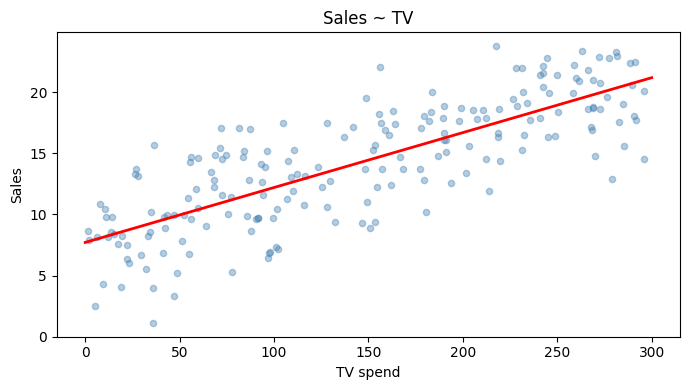

In [2]:
# Tutorial: Sales ~ TV
X = sm.add_constant(df['TV'])
model_tv = sm.OLS(df['Sales'], X).fit()
print(model_tv.summary().tables[1])
print(f"R² = {model_tv.rsquared:.3f}   RSE = {np.sqrt(model_tv.mse_resid):.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df['TV'], df['Sales'], alpha=0.4, s=20, color='steelblue')
x_line = np.linspace(0, 300, 200)
ax.plot(x_line, model_tv.params[0] + model_tv.params[1]*x_line, 'r-', lw=2)
ax.set(xlabel='TV spend', ylabel='Sales', title='Sales ~ TV')
plt.tight_layout(); plt.show()

### 🔧 Exercise 1 — Fit Sales ~ Radio

**Tasks:**
1. Fit OLS: `Sales ~ Radio`. Print the coefficient table.
2. Interpret the slope: what does a 1-unit increase in Radio spend mean for Sales?
3. Plot scatter + regression line.
4. Compare R² and RSE with the TV model — which predictor explains more variance?

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.8958      0.611     16.205      0.000       8.692      11.100
Radio          0.1719      0.021      8.205      0.000       0.131       0.213
R² = 0.254   RSE = 4.33


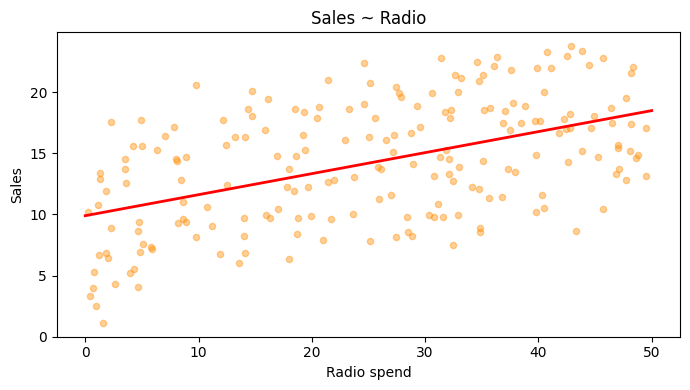

In [3]:
# ── SOLUTION Exercise 1 ──────────────────────────────────────────────────────
X_r = sm.add_constant(df['Radio'])
model_r = sm.OLS(df['Sales'], X_r).fit()
print(model_r.summary().tables[1])
print(f"R² = {model_r.rsquared:.3f}   RSE = {np.sqrt(model_r.mse_resid):.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df['Radio'], df['Sales'], alpha=0.4, s=20, color='darkorange')
x_line = np.linspace(0, 50, 200)
ax.plot(x_line, model_r.params[0] + model_r.params[1]*x_line, 'r-', lw=2)
ax.set(xlabel='Radio spend', ylabel='Sales', title='Sales ~ Radio')
plt.tight_layout(); plt.show()
# TV has higher R² → TV explains more variance in Sales

---
## Part 2 — Residual Diagnostics

### 2.1 Tutorial: residuals vs fitted and Q-Q plot

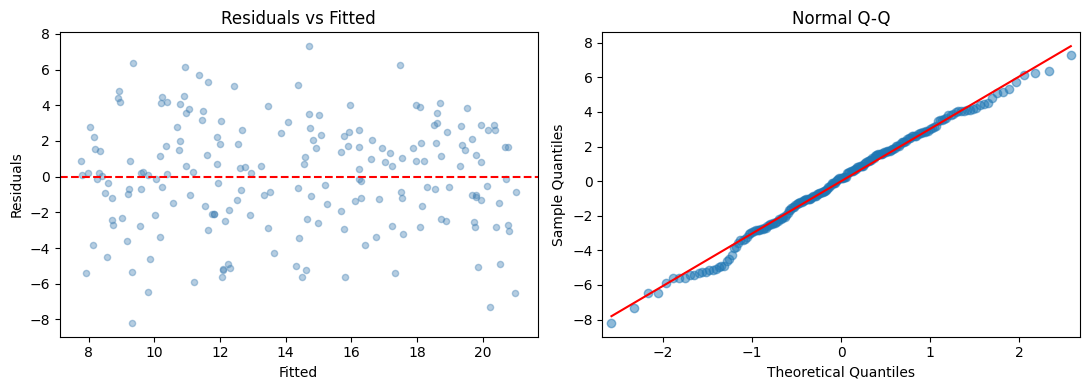

In [4]:
# Tutorial: diagnostics for TV model
fitted = model_tv.fittedvalues
resid  = model_tv.resid

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(fitted, resid, alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', ls='--')
axes[0].set(xlabel='Fitted', ylabel='Residuals', title='Residuals vs Fitted')
sm.qqplot(resid, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Normal Q-Q')
plt.tight_layout(); plt.show()

### 🔧 Exercise 2 — Diagnose the Radio model

**Tasks:**
1. Produce a residuals-vs-fitted plot and Q-Q plot for the `Radio` model.
2. Do the residuals look random? Is there a pattern?
3. What would a systematic curve in the residual plot suggest?

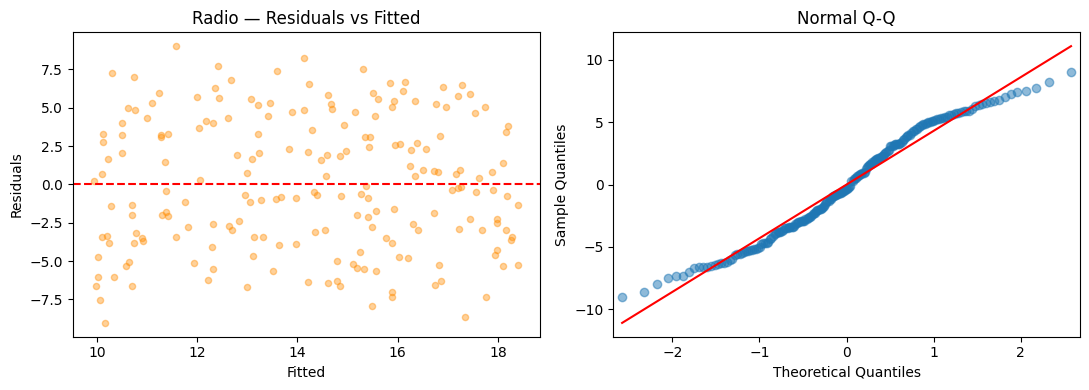

In [5]:
# ── SOLUTION Exercise 2 ──────────────────────────────────────────────────────
fitted_r = model_r.fittedvalues
resid_r  = model_r.resid

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(fitted_r, resid_r, alpha=0.4, s=20, color='darkorange')
axes[0].axhline(0, color='red', ls='--')
axes[0].set(xlabel='Fitted', ylabel='Residuals', title='Radio — Residuals vs Fitted')
sm.qqplot(resid_r, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Normal Q-Q')
plt.tight_layout(); plt.show()
# Residuals appear random → OLS assumptions roughly met

---
## Part 3 — Multiple Regression

### 3.1 Tutorial: Sales ~ TV + Radio

In [6]:
# Tutorial: two-predictor model
X2 = sm.add_constant(df[['TV', 'Radio']])
model2 = sm.OLS(df['Sales'], X2).fit()
print(model2.summary().tables[1])
print(f"R² = {model2.rsquared:.3f}   Adj-R² = {model2.rsquared_adj:.3f}")
print(f"F = {model2.fvalue:.1f}   p(F) = {model2.f_pvalue:.2e}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0724      0.283     10.858      0.000       2.514       3.630
TV             0.0457      0.001     37.270      0.000       0.043       0.048
Radio          0.1793      0.007     24.217      0.000       0.165       0.194
R² = 0.907   Adj-R² = 0.906
F = 964.2   p(F) = 1.79e-102


### 🔧 Exercise 3 — Add News to the model

**Tasks:**
1. Fit `Sales ~ TV + Radio + News`. Print the table.
2. Compare R², Adj-R², and F-stat with the two-predictor model.
3. Is `News` a statistically significant predictor (p < 0.05)?
4. Which model would you prefer, and why?

In [7]:
# ── SOLUTION Exercise 3 ──────────────────────────────────────────────────────
X3 = sm.add_constant(df[['TV', 'Radio', 'News']])
model3 = sm.OLS(df['Sales'], X3).fit()
print(model3.summary().tables[1])
print(f"R² = {model3.rsquared:.3f}   Adj-R² = {model3.rsquared_adj:.3f}")
print(f"F = {model3.fvalue:.1f}   p(F) = {model3.f_pvalue:.2e}")
# News p-value is large → not significant; TV+Radio model preferred

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8157      0.357      7.892      0.000       2.112       3.519
TV             0.0416      0.004     11.225      0.000       0.034       0.049
Radio          0.1804      0.007     24.197      0.000       0.166       0.195
News           0.0140      0.012      1.179      0.240      -0.009       0.037
R² = 0.908   Adj-R² = 0.907
F = 644.5   p(F) = 3.15e-101


---
## Part 4 — Multicollinearity (VIF)

### 4.1 Tutorial: VIF values

> Rule of thumb: VIF > 5 → moderate, VIF > 10 → serious problem.

In [8]:
# Tutorial: VIF for TV, Radio, News
X_vif = df[['TV', 'Radio', 'News']].assign(const=1)
vif = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif[vif['Feature'] != 'const'].to_string(index=False))

Feature      VIF
     TV 9.150002
  Radio 1.016680
   News 9.184626


### 🔧 Exercise 4 — Fix multicollinearity

**Tasks:**
1. Which predictor has VIF > 5? Drop it and re-fit the model.
2. Check VIF again on the reduced model. Are all values now below 5?
3. Does dropping the collinear predictor change R² much? What does that tell you?

In [9]:
# ── SOLUTION Exercise 4 ──────────────────────────────────────────────────────
# News is collinear with TV (VIF > 5) — drop it
X_clean = sm.add_constant(df[['TV', 'Radio']])
m_clean = sm.OLS(df['Sales'], X_clean).fit()
print(f"R² without News: {m_clean.rsquared:.3f}  (with News: {model3.rsquared:.3f})")

X_vif2 = df[['TV', 'Radio']].assign(const=1)
vif2 = pd.DataFrame({
    'Feature': X_vif2.columns,
    'VIF': [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])]
})
print(vif2[vif2['Feature'] != 'const'].to_string(index=False))
# VIF now near 1 — no multicollinearity; R² barely changed → News added no real information

R² without News: 0.907  (with News: 0.908)
Feature      VIF
     TV 1.000723
  Radio 1.000723


---
## Part 5 — Train / Test Evaluation

### 5.1 Tutorial: out-of-sample RMSE

In [10]:
# Tutorial: 80/20 split on TV+Radio model
X_all = sm.add_constant(df[['TV', 'Radio']])
y = df['Sales']
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y, test_size=0.2, random_state=0)

m_tr = sm.OLS(y_tr, X_tr).fit()
y_hat = m_tr.predict(X_te)
print(f"TV+Radio  — Test RMSE: {np.sqrt(mean_squared_error(y_te, y_hat)):.3f}")
r2_te  = 1 - np.sum((y_te - y_hat)**2) / np.sum((y_te - y_te.mean())**2)
mse_te = mean_squared_error(y_te, y_hat)
print(f"TV+Radio  — Test MSE: {mse_te:.3f}  RMSE: {np.sqrt(mse_te):.3f}  R²: {r2_te:.3f}")
print("MSE = mean squared residual (same units²); R² = fraction of variance explained (0–1)")

TV+Radio  — Test RMSE: 1.541


### 🔧 Exercise 5 — Compare models out-of-sample

**Tasks:**
1. Using the same split, fit `Sales ~ TV + Radio + News` on the training set.
2. Compute test RMSE for both models.
3. Does the extra predictor help out-of-sample? What does this suggest about over-fitting?
4. Compute both **MSE** and **R²** for the two models. Does adding News improve R²?

In [11]:
# ── SOLUTION Exercise 5 ──────────────────────────────────────────────────────
X_all3 = sm.add_constant(df[['TV', 'Radio', 'News']])
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_all3, y, test_size=0.2, random_state=0)
m_tr3 = sm.OLS(y_tr3, X_tr3).fit()
y_hat3 = m_tr3.predict(X_te3)
print(f"TV+Radio+News — Test RMSE: {np.sqrt(mean_squared_error(y_te3, y_hat3)):.3f}")
print(f"TV+Radio      — Test RMSE: {np.sqrt(mean_squared_error(y_te, y_hat)):.3f}")
# Similar test RMSE → News does not help; collinear predictor adds noise

print(f"TV+Radio+News — Test MSE: {mean_squared_error(y_te3, y_hat3):.3f}   R²: {m_tr3.rsquared:.3f}")
print(f"TV+Radio      — Test MSE: {mean_squared_error(y_te,  y_hat):.3f}   R²: {m_tr.rsquared:.3f}")
# MSE and R² both confirm News adds little out-of-sample

TV+Radio+News — Test RMSE: 1.526
TV+Radio      — Test RMSE: 1.541


---
## Summary

| Concept | Key idea |
|---|---|
| **OLS** | Minimises RSS; slope = change in y per unit x |
| **R²** | Fraction of variance explained (0–1); higher is better |
| **MSE** | Mean squared error — average (prediction − actual)²; lower is better; same units² as y² |
| **Residuals** | Should be random — a pattern means the model is missing something |
| **Multiple regression** | Use Adj-R² and F-test to justify extra predictors |
| **VIF** | Detects multicollinearity; drop predictors with VIF > 10 |